# Loan Risk Assessment

## Author : Khor Kai Xian

# Data Loading

In [3]:
import pandas as pd

In [4]:
loan = pd.read_csv('loan.csv')
payment = pd.read_csv('payment.csv')
clarity = pd.read_csv('clarity_underwriting_variables.csv', low_memory=False)

print(f"loan.csv:     {loan.shape}")
print(f"payment.csv:  {payment.shape}")
print(f"clarity.csv:  {clarity.shape}")


loan.csv:     (577682, 19)
payment.csv:  (689364, 9)
clarity.csv:  (49752, 54)


In [5]:
loan.head()

,loanId,anon_ssn,payFrequency,apr,applicationDate,originated,originatedDate,nPaidOff,approved,isFunded,loanStatus,loanAmount,originallyScheduledPaymentAmount,state,leadType,leadCost,fpStatus,clarityFraudId,hasCF
0,LL-I-07399092,beff4989be82aab4a5b47679216942fd,B,360.0,2016-02-23T17:29:01.940000,False,NaN,0.0,False,0,Withdrawn Application,500.0,978.27,IL,bvMandatory,6,NaN,5669ef78e4b0c9d3936440e6,1
1,LL-I-06644937,464f5d9ae4fa09ece4048d949191865c,B,199.0,2016-01-19T22:07:36.778000,True,2016-01-20T15:49:18.846000,0.0,True,1,Paid Off Loan,3000.0,6395.19,CA,prescreen,0,Checked,569eb3a3e4b096699f685d64,1
2,LL-I-10707532,3c174ae9e2505a5f9ddbff9843281845,B,590.0,2016-08-01T13:51:14.709000,False,NaN,0.0,False,0,Withdrawn Application,400.0,1199.45,MO,bvMandatory,3,NaN,579eab11e4b0d0502870ef2f,1
3,LL-I-02272596,9be6f443bb97db7e95fa0c281d34da91,B,360.0,2015-08-06T23:58:08.880000,False,NaN,0.0,False,0,Withdrawn Application,500.0,1074.05,IL,bvMandatory,3,NaN,555b1e95e4b0f6f11b267c18,1
4,LL-I-09542882,63b5494f60b5c19c827c7b068443752c,B,590.0,2016-06-05T22:31:34.304000,False,NaN,0.0,False,0,Rejected,350.0,814.37,NV,bvMandatory,3,NaN,5754a91be4b0c6a2bf424772,1


In [6]:
payment.head()

,loanId,installmentIndex,isCollection,paymentDate,principal,fees,paymentAmount,paymentStatus,paymentReturnCode
0,LL-I-00000021,1,False,2014-12-19T05:00:00,22.33,147.28,169.61,Checked,NaN
1,LL-I-00000021,2,False,2015-01-02T05:00:00,26.44,143.17,169.61,Checked,NaN
2,LL-I-00000021,3,False,2015-01-16T05:00:00,31.30,138.31,169.61,Checked,NaN
3,LL-I-00000021,4,False,2015-01-30T05:00:00,37.07,132.54,169.61,Checked,NaN
4,LL-I-00000021,5,False,2015-02-13T05:00:00,43.89,125.72,169.61,Checked,NaN


In [7]:
clarity.head()

,.underwritingdataclarity.clearfraud.clearfraudinquiry.thirtydaysago,.underwritingdataclarity.clearfraud.clearfraudinquiry.twentyfourhoursago,.underwritingdataclarity.clearfraud.clearfraudinquiry.oneminuteago,.underwritingdataclarity.clearfraud.clearfraudinquiry.onehourago,.underwritingdataclarity.clearfraud.clearfraudinquiry.ninetydaysago,.underwritingdataclarity.clearfraud.clearfraudinquiry.sevendaysago,.underwritingdataclarity.clearfraud.clearfraudinquiry.tenminutesago,.underwritingdataclarity.clearfraud.clearfraudinquiry.fifteendaysago,.underwritingdataclarity.clearfraud.clearfraudinquiry.threesixtyfivedaysago,.underwritingdataclarity.clearfraud.clearfraudindicator.inquiryonfilecurrentaddressconflict,...,.underwritingdataclarity.clearfraud.clearfraudidentityverification.phonematchtypedescription,.underwritingdataclarity.clearfraud.clearfraudidentityverification.overallmatchresult,.underwritingdataclarity.clearfraud.clearfraudidentityverification.phonetype,.underwritingdataclarity.clearfraud.clearfraudidentityverification.ssndobreasoncode,.underwritingdataclarity.clearfraud.clearfraudidentityverification.ssnnamereasoncode,.underwritingdataclarity.clearfraud.clearfraudidentityverification.nameaddressreasoncode,.underwritingdataclarity.clearfraud.clearfraudidentityverification.ssndobmatch,.underwritingdataclarity.clearfraud.clearfraudidentityverification.overallmatchreasoncode,clearfraudscore,underwritingid
0,8.0,2.0,2.0,2.0,8.0,2.0,2.0,5.0,10.0,False,...,(M) Mobile Phone,partial,NaN,NaN,NaN,A8,match,6.0,871.0,54cbffcee4b0ba763e43144d
1,5.0,2.0,2.0,2.0,11.0,2.0,2.0,4.0,21.0,True,...,(M) Mobile Phone,partial,NaN,NaN,NaN,NaN,match,11.0,397.0,54cc0408e4b0418d9a7f78af
2,9.0,4.0,2.0,3.0,10.0,8.0,2.0,9.0,25.0,False,...,(M) Mobile Phone,match,NaN,NaN,NaN,NaN,match,1.0,572.0,54cc0683e4b0418d9a80adb6
3,3.0,2.0,2.0,2.0,9.0,2.0,2.0,2.0,9.0,False,...,(M) Mobile Phone,partial,NaN,NaN,NaN,NaN,match,11.0,838.0,54cc0780e4b0ba763e43b74a
4,5.0,5.0,2.0,2.0,6.0,5.0,2.0,5.0,6.0,False,...,(M) Mobile Phone,match,NaN,NaN,NaN,NaN,match,1.0,768.0,54cc1d67e4b0ba763e445b45


# Basic Data Understanding

In [8]:
loan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 577682 entries, 0 to 577681
Data columns (total 19 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   loanId                            577426 non-null  object 
 1   anon_ssn                          577682 non-null  object 
 2   payFrequency                      576409 non-null  object 
 3   apr                               573760 non-null  float64
 4   applicationDate                   577682 non-null  object 
 5   originated                        577682 non-null  bool   
 6   originatedDate                    46044 non-null   object 
 7   nPaidOff                          577658 non-null  float64
 8   approved                          577682 non-null  bool   
 9   isFunded                          577682 non-null  int64  
 10  loanStatus                        577291 non-null  object 
 11  loanAmount                        575432 non-null  f

In [9]:
payment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 689364 entries, 0 to 689363
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   loanId             689364 non-null  object 
 1   installmentIndex   689364 non-null  int64  
 2   isCollection       689364 non-null  bool   
 3   paymentDate        689364 non-null  object 
 4   principal          689364 non-null  float64
 5   fees               689364 non-null  float64
 6   paymentAmount      689364 non-null  float64
 7   paymentStatus      525307 non-null  object 
 8   paymentReturnCode  31533 non-null   object 
dtypes: bool(1), float64(3), int64(1), object(4)
memory usage: 42.7+ MB


In [10]:
clarity.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49752 entries, 0 to 49751
Data columns (total 54 columns):
 #   Column                                                                                               Non-Null Count  Dtype  
---  ------                                                                                               --------------  -----  
 0   .underwritingdataclarity.clearfraud.clearfraudinquiry.thirtydaysago                                  49750 non-null  float64
 1   .underwritingdataclarity.clearfraud.clearfraudinquiry.twentyfourhoursago                             49750 non-null  float64
 2   .underwritingdataclarity.clearfraud.clearfraudinquiry.oneminuteago                                   49750 non-null  float64
 3   .underwritingdataclarity.clearfraud.clearfraudinquiry.onehourago                                     49750 non-null  float64
 4   .underwritingdataclarity.clearfraud.clearfraudinquiry.ninetydaysago                                  49750

# Descriptive Statistics

In [11]:
loan.describe()

,apr,nPaidOff,isFunded,loanAmount,originallyScheduledPaymentAmount,leadCost,hasCF
count,573760.000000,577658.000000,577682.000000,575432.000000,577682.000000,577682.000000,577682.000000
mean,553.080972,0.037887,0.067480,514.245084,1428.897209,7.854389,0.619187
std,110.046159,0.333366,0.250852,320.939929,925.009141,12.853451,0.485587
min,0.000000,0.000000,0.000000,0.000000,-816.710000,0.000000,0.000000
25%,490.000000,0.000000,0.000000,350.000000,1023.640000,3.000000,0.000000
50%,590.000000,0.000000,0.000000,500.000000,1245.250000,3.000000,1.000000
75%,601.000000,0.000000,0.000000,500.000000,1615.660000,6.000000,1.000000
max,705.590000,21.000000,1.000000,5000.000000,19963.630000,200.000000,1.000000


In [12]:
payment.describe()

,installmentIndex,principal,fees,paymentAmount
count,689364.000000,689364.000000,689364.000000,689364.000000
mean,10.553222,45.557543,67.003994,112.680232
std,8.049530,81.724683,59.789510,105.783710
min,1.000000,-303.370000,-42.560000,-337.700000
25%,5.000000,13.180000,28.820000,56.810000
50%,9.000000,27.610000,51.300000,86.340000
75%,14.000000,53.380000,86.440000,135.090000
max,105.000000,4000.000000,1257.710000,4063.600000


In [13]:
clarity.describe()

,.underwritingdataclarity.clearfraud.clearfraudinquiry.thirtydaysago,.underwritingdataclarity.clearfraud.clearfraudinquiry.twentyfourhoursago,.underwritingdataclarity.clearfraud.clearfraudinquiry.oneminuteago,.underwritingdataclarity.clearfraud.clearfraudinquiry.onehourago,.underwritingdataclarity.clearfraud.clearfraudinquiry.ninetydaysago,.underwritingdataclarity.clearfraud.clearfraudinquiry.sevendaysago,.underwritingdataclarity.clearfraud.clearfraudinquiry.tenminutesago,.underwritingdataclarity.clearfraud.clearfraudinquiry.fifteendaysago,.underwritingdataclarity.clearfraud.clearfraudinquiry.threesixtyfivedaysago,.underwritingdataclarity.clearfraud.clearfraudindicator.totalnumberoffraudindicators,.underwritingdataclarity.clearfraud.clearfraudindicator.maxnumberofssnswithanybankaccount,.underwritingdataclarity.clearfraud.clearfraudidentityverification.overallmatchreasoncode,clearfraudscore
count,49750.000000,49750.000000,49750.000000,49750.000000,49750.000000,49750.000000,49750.000000,49750.000000,49750.000000,49735.000000,49735.000000,49720.000000,49615.000000
mean,7.313628,4.601990,2.343980,4.006874,10.554513,5.423799,3.292121,6.155578,20.302291,2.118327,7.202554,11.728842,683.769787
std,6.327122,3.302288,1.436345,2.697831,10.450845,4.110483,2.109667,4.952620,23.771239,1.254602,79.908530,14.116701,126.205372
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,122.000000
25%,3.000000,3.000000,1.000000,3.000000,4.000000,3.000000,2.000000,3.000000,6.000000,1.000000,1.000000,1.000000,592.000000
50%,5.000000,3.000000,3.000000,3.000000,7.000000,4.000000,3.000000,5.000000,12.000000,2.000000,1.000000,11.000000,691.000000
75%,9.000000,5.000000,3.000000,5.000000,13.000000,6.000000,4.000000,7.000000,25.000000,3.000000,2.000000,15.000000,783.000000
max,89.000000,60.000000,16.000000,42.000000,202.000000,64.000000,35.000000,83.000000,438.000000,8.000000,4056.000000,125.000000,965.000000


# Target Variable Defining 

In [14]:
loan["loanStatus"].unique()

array(['Withdrawn Application', 'Paid Off Loan', 'Rejected', 'New Loan',
       'Internal Collection', 'CSR Voided New Loan',
       'External Collection', 'Returned Item', 'Customer Voided New Loan',
       'Credit Return Void', 'Pending Paid Off', 'Charged Off Paid Off',
       nan, 'Settled Bankruptcy', 'Settlement Paid Off', 'Charged Off',
       'Pending Rescind', 'Customver Voided New Loan',
       'Pending Application', 'Voided New Loan',
       'Pending Application Fee', 'Settlement Pending Paid Off'],
      dtype=object)

In [15]:
# Target variable selection justification:
# I only model funded loans (isFunded == 1) because the risk question only applies once a loan is disbursed. Non-funded rows (isFunded == 0)are excluded.

funded = loan[loan['isFunded'] == 1].copy()

# Among funded loans, I define the binary target using loanStatus column from the loan.csv:
#   Bad  (1): loan resulted in a financial loss or collection action
#   Good (0): loan was fully or partially repaid
#   Drop    : outcome is still unknown (New Loan, Pending, Voided Loan) — including these would introduce label noise / future leakage.

# Drop : Withdrawn Application, Rejected, New Loan, CSR Voided New Loan, Customer Voided New Loan, Credit Return Void, Pending Paid Off, Pending Rescind, Customer Voided New Loan, Pending Application, Voided New Loan, Pending Application Fee, Settlement Pending Paid Off

bad_statuses = [
    'External Collection',
    'Internal Collection',
    'Settled Bankruptcy',
    'Charged Off',
    'Charged Off Paid Off',
    'Returned Item',        # missed 1 payment — treated as bad (conservative)
]

good_statuses = [
    'Paid Off Loan',
    'Settlement Paid Off',
]

# Keep only rows with known outcomes
df = funded[funded['loanStatus'].isin(bad_statuses + good_statuses)].copy()
df['target'] = df['loanStatus'].isin(bad_statuses).astype(int)

print(f"Total funded loans:          {len(funded):,}")
print(f"Dropped (unknown outcome):   {len(funded) - len(df):,}")
print(f"Modelling dataset:           {len(df):,}")
print()
print(df['target'].value_counts().rename({0: 'Good (0)', 1: 'Bad (1)'}))
print(f"\nBad rate: {df['target'].mean():.1%}")

Total funded loans:          38,982
Dropped (unknown outcome):   8,282
Modelling dataset:           30,700

target
Bad (1)     18565
Good (0)    12135
Name: count, dtype: int64

Bad rate: 60.5%


# Feature Engineering for loan.csv

In [16]:
loan.var(numeric_only=True)
loan.select_dtypes(include='bool').var()

originated    0.073297
approved      0.064502
dtype: float64

In [17]:
loan['isFunded'].var()

0.06292658644126677

In [18]:
# Extract derived features BEFORE dropping source columns
df['applicationDate'] = pd.to_datetime(df['applicationDate'], format='ISO8601')
df['app_month'] = df['applicationDate'].dt.month
df['app_year']  = df['applicationDate'].dt.year
df['is_repeat_customer'] = (df['nPaidOff'] > 0).astype(int)

# Drop irrelevant columns

cols_to_drop = [
    'anon_ssn',         # hashed ID — repeat customer captured by nPaidOff
    'applicationDate',  # raw timestamp — replaced by app_month/year
    'originatedDate',   # post-application date — not known at application time
    'originated',       # all True after funding filter — zero variance
    'approved',         # all True after funding filter — zero variance
    'isFunded',         # all 1 after funding filter — zero variance
    'loanStatus',       # target variable — never use as feature
    'fpStatus',         # post-funding outcome — not available at application time
    'hasCF',            # redundant — replaced by has_clarity_data after merge
]

df_clean = df.drop(columns=cols_to_drop)

print("Shape before dropping:", df.shape)
print("Shape after dropping: ", df_clean.shape)
print()
print("Columns remaining (loanId + clarityFraudId kept for Cell 6 merge):")
for col in df_clean.columns:
    print(f"  ✓ {col}")

Shape before dropping: (30700, 23)
Shape after dropping:  (30700, 14)

Columns remaining (loanId + clarityFraudId kept for Cell 6 merge):
  ✓ loanId
  ✓ payFrequency
  ✓ apr
  ✓ nPaidOff
  ✓ loanAmount
  ✓ originallyScheduledPaymentAmount
  ✓ state
  ✓ leadType
  ✓ leadCost
  ✓ clarityFraudId
  ✓ target
  ✓ app_month
  ✓ app_year
  ✓ is_repeat_customer


# Feature Engineering for clarity_underwriting_variables.csv

In [19]:
pd.set_option('display.max_rows', None)

(clarity.isnull().mean() * 100).sort_values(ascending=False)

.underwritingdataclarity.clearfraud.clearfraudidentityverification.phonetype                           96.954896
.underwritingdataclarity.clearfraud.clearfraudidentityverification.ssnnamereasoncodedescription        94.635392
.underwritingdataclarity.clearfraud.clearfraudidentityverification.ssnnamereasoncode                   94.635392
.underwritingdataclarity.clearfraud.clearfraudidentityverification.nameaddressreasoncodedescription    88.689902
.underwritingdataclarity.clearfraud.clearfraudidentityverification.nameaddressreasoncode               88.689902
.underwritingdataclarity.clearfraud.clearfraudidentityverification.ssndobreasoncode                    81.851986
.underwritingdataclarity.clearfraud.clearfraudindicator.driverlicenseinconsistentwithonfile            79.789757
.underwritingdataclarity.clearfraud.clearfraudindicator.workphonepreviouslylistedashomephone           56.954494
.underwritingdataclarity.clearfraud.clearfraudindicator.workphonepreviouslylistedascellphone    

Drop phonetype 97.0%❌  
Drop ssnnamereasoncode 94.6%❌  
Drop ssnnamereasoncodedescription 94.6%❌   
Drop nameaddressreasoncode 88.7%❌   
Drop nameaddressreasoncodedescription 88.7%❌   
Drop ssndobreasoncode 81.9%❌   
Drop driverlicenseinconsistentwithonfile 79.8%❌  
Drop workphonepreviouslylistedascellphone 57.0%❌   
Drop workphonepreviouslylistedashomephone 57.0%❌   

In [20]:
bool_cols = [
    col for col in clarity.columns
    if clarity[col].dropna().astype(str).str.upper().isin(['TRUE', 'FALSE']).mean() > 0.9
]
for col in bool_cols:
    print("\n", col)
    print(clarity[col].astype(str).str.upper().value_counts())


 .underwritingdataclarity.clearfraud.clearfraudindicator.inquiryonfilecurrentaddressconflict
.underwritingdataclarity.clearfraud.clearfraudindicator.inquiryonfilecurrentaddressconflict
FALSE    37474
TRUE     12238
NAN         40
Name: count, dtype: int64

 .underwritingdataclarity.clearfraud.clearfraudindicator.telephonenumberinconsistentwithaddress
.underwritingdataclarity.clearfraud.clearfraudindicator.telephonenumberinconsistentwithaddress
TRUE     45781
FALSE     3931
NAN         40
Name: count, dtype: int64

 .underwritingdataclarity.clearfraud.clearfraudindicator.inquiryageyoungerthanssnissuedate
.underwritingdataclarity.clearfraud.clearfraudindicator.inquiryageyoungerthanssnissuedate
FALSE    49569
TRUE       143
NAN         40
Name: count, dtype: int64

 .underwritingdataclarity.clearfraud.clearfraudindicator.onfileaddresscautious
.underwritingdataclarity.clearfraud.clearfraudindicator.onfileaddresscautious
FALSE    49706
NAN         40
TRUE         6
Name: count, dtype: int6

# Remove Columns that near zero variance (TRUE is less than 1%)  
Drop onfileaddresscautious0.0%❌   
Drop inputssninvalid0.0%❌  
Drop inputssnrecordedasdeceased0.0%❌   
Drop bestonfilessnissuedatecannotbeverified0.0%❌   
Drop bestonfilessnrecordedasdeceased0.0%❌  
Drop inquiryaddresscautious0.0%❌  
Drop inquiryageyoungerthanssnissuedate0.3%❌   
Drop inputssnissuedatecannotbeverified0.2%❌  
Drop creditestablishedpriortossnissuedate0.4%❌   


Drop tenminutesago, oneminuteago, onehourago, twentyfourhoursago, fifteendaysago - Highly correlated with inq_7d, inq_30d — redundant time windows❌  
Drop phonematchtypedescription - Identical text description of phonematchtype — redundant❌  

Drop telephonenumberinconsistentwithaddress - TRUE 92% of the time — no discriminating power❌  
Drop overallmatchreasoncodeNumeric code with 75 unique values — needs complex mapping❌  
Drop phonematchresultRedundant with phonematchtype❌  

In [21]:
# Rename long column names for readability


clarity_renamed = clarity.rename(columns={
    '.underwritingdataclarity.clearfraud.clearfraudinquiry.thirtydaysago':          'inq_30d',
    '.underwritingdataclarity.clearfraud.clearfraudinquiry.ninetydaysago':           'inq_90d',
    '.underwritingdataclarity.clearfraud.clearfraudinquiry.sevendaysago':            'inq_7d',
    '.underwritingdataclarity.clearfraud.clearfraudinquiry.threesixtyfivedaysago':   'inq_365d',
    '.underwritingdataclarity.clearfraud.clearfraudindicator.totalnumberoffraudindicators':       'n_fraud_indicators',
    '.underwritingdataclarity.clearfraud.clearfraudindicator.inquiryaddresshighrisk':             'addr_high_risk',
    '.underwritingdataclarity.clearfraud.clearfraudindicator.onfileaddresshighrisk':              'onfile_addr_high_risk',
    '.underwritingdataclarity.clearfraud.clearfraudindicator.morethan3inquiriesinthelast30days':  'many_inq_30d',
    '.underwritingdataclarity.clearfraud.clearfraudindicator.highprobabilityssnbelongstoanother': 'ssn_belongs_to_another',
    '.underwritingdataclarity.clearfraud.clearfraudindicator.inquiryaddressnonresidential':       'inq_addr_nonresidential',
    '.underwritingdataclarity.clearfraud.clearfraudindicator.onfileaddressnonresidential':        'onfile_addr_nonresidential',
    '.underwritingdataclarity.clearfraud.clearfraudindicator.ssnreportedmorefrequentlyforanother':'ssn_reported_for_another',
    '.underwritingdataclarity.clearfraud.clearfraudindicator.currentaddressreportedbytradeopenlt90days': 'addr_reported_lt90d',
    '.underwritingdataclarity.clearfraud.clearfraudindicator.currentaddressreportedbynewtradeonly':      'addr_new_trade_only',
    '.underwritingdataclarity.clearfraud.clearfraudindicator.inquirycurrentaddressnotonfile':            'inq_addr_not_on_file',
    '.underwritingdataclarity.clearfraud.clearfraudindicator.telephonenumberinconsistentwithstate':      'phone_inconsistent_state',
    '.underwritingdataclarity.clearfraud.clearfraudindicator.creditestablishedbeforeage18':              'credit_before_age18',
    '.underwritingdataclarity.clearfraud.clearfraudindicator.maxnumberofssnswithanybankaccount':         'max_ssns_bank_account',
    '.underwritingdataclarity.clearfraud.clearfraudidentityverification.overallmatchresult':  'identity_match',
    '.underwritingdataclarity.clearfraud.clearfraudidentityverification.ssndobmatch':         'ssndob_match',
    '.underwritingdataclarity.clearfraud.clearfraudidentityverification.ssnnamematch':        'ssn_name_match',
    '.underwritingdataclarity.clearfraud.clearfraudidentityverification.nameaddressmatch':    'name_address_match',
    'clearfraudscore': 'fraud_score',
    'underwritingid':  'clarityFraudId',
    '.underwritingdataclarity.clearfraud.clearfraudindicator.driverlicenseformatinvalid':          'driver_license_invalid',
    '.underwritingdataclarity.clearfraud.clearfraudindicator.inquiryonfilecurrentaddressconflict': 'inq_addr_conflict',
    '.underwritingdataclarity.clearfraud.clearfraudidentityverification.phonematchtype':            'phone_match_type',
})

# Columns to keep with justification
clarity_cols = [
    'clarityFraudId',
    # Overall score
    'fraud_score',
    # Inquiry velocity (meaningful time windows only)
    'inq_7d', 'inq_30d', 'inq_90d', 'inq_365d',
    # Fraud indicators (non-zero variance, meaningful signal)
    'n_fraud_indicators', 'many_inq_30d',
    'addr_high_risk', 'onfile_addr_high_risk',
    'inq_addr_nonresidential', 'onfile_addr_nonresidential',
    'ssn_belongs_to_another', 'ssn_reported_for_another',
    'addr_reported_lt90d', 'addr_new_trade_only',
    'inq_addr_not_on_file', 'phone_inconsistent_state',
    'credit_before_age18', 'max_ssns_bank_account',
    # Identity verification
    'identity_match', 'ssndob_match',
    'ssn_name_match', 'name_address_match',
    'driver_license_invalid',    
    'inq_addr_conflict',         
    'phone_match_type',          
]

clarity_features = clarity_renamed[clarity_cols].copy()

# Convert boolean columns to int
bool_cols = [
    'addr_high_risk', 'onfile_addr_high_risk', 'many_inq_30d',
    'ssn_belongs_to_another', 'inq_addr_nonresidential',
    'onfile_addr_nonresidential', 'ssn_reported_for_another',
    'addr_reported_lt90d', 'addr_new_trade_only',
    'inq_addr_not_on_file', 'phone_inconsistent_state',
    'credit_before_age18',
    'driver_license_invalid',    
    'inq_addr_conflict',        
]
for col in bool_cols:
    clarity_features[col] = (clarity_features[col]
                             .astype(str).str.upper()
                             .map({'TRUE': 1, 'FALSE': 0}))

print("Clarity features shape:", clarity_features.shape)
print(f"Columns kept: {len(clarity_cols)-1} features + join key")
print()
print("Dropped reasons summary:")
print("  - Too many nulls (>50%):          9 columns")
print("  - Near-zero variance (<1% TRUE):  9 columns")
print("  - Redundant time windows:         5 columns")
print("  - Redundant text descriptions:    1 column")
print("  - No discriminating power:        3 columns")
print("  - Total dropped:                 27 columns")
print(f"  - Total kept:                    27 features (including join key)")
for col in clarity_features.columns:
    print(" -", col)

Clarity features shape: (49752, 27)
Columns kept: 26 features + join key

Dropped reasons summary:
  - Too many nulls (>50%):          9 columns
  - Near-zero variance (<1% TRUE):  9 columns
  - Redundant time windows:         5 columns
  - Redundant text descriptions:    1 column
  - No discriminating power:        3 columns
  - Total dropped:                 27 columns
  - Total kept:                    27 features (including join key)
 - clarityFraudId
 - fraud_score
 - inq_7d
 - inq_30d
 - inq_90d
 - inq_365d
 - n_fraud_indicators
 - many_inq_30d
 - addr_high_risk
 - onfile_addr_high_risk
 - inq_addr_nonresidential
 - onfile_addr_nonresidential
 - ssn_belongs_to_another
 - ssn_reported_for_another
 - addr_reported_lt90d
 - addr_new_trade_only
 - inq_addr_not_on_file
 - phone_inconsistent_state
 - credit_before_age18
 - max_ssns_bank_account
 - identity_match
 - ssndob_match
 - ssn_name_match
 - name_address_match
 - driver_license_invalid
 - inq_addr_conflict
 - phone_match_type


# Merge Dataset

In [28]:
model_df = df_clean.copy()

# Merge clarity features (join key: clarityFraudId)
model_df = model_df.merge(clarity_features, on='clarityFraudId', how='left')

# Merge payment_eda for EDA visualisations ONLY
# These columns will NOT be included in feature_cols 
model_df = model_df.merge(payment_eda, on='loanId', how='left')

# Flag: did we get clarity data for this loan?
model_df['has_clarity_data'] = model_df['fraud_score'].notna().astype(int)

# Now drop the join keys — no longer needed after merging
model_df = model_df.drop(columns=['clarityFraudId', 'loanId'])

print("Final merged shape:", model_df.shape)
print()
print("Null counts in key columns:")
print(model_df[['apr', 'loanAmount', 'fraud_score',
                'first_payment_failed', 'pct_payments_failed']].isnull().sum())

Final merged shape: (30700, 50)

Null counts in key columns:
apr                        0
loanAmount                 0
fraud_score             5249
first_payment_failed      19
pct_payments_failed       19
dtype: int64


# Data Cleaning 

In [29]:
# Data cleaning on merged dataset

print("=== BEFORE CLEANING ===")
print(f"Shape: {model_df.shape}")
print()

# ── 1. Duplicates ──────────────────────────────────────────────────────────
print("--- Duplicates ---")
print(f"Duplicate rows: {model_df.duplicated().sum()}")
print(f"Note: Same customer can appear multiple times with different")
print(f"      loans — this is expected and not treated as duplicates.")
print()

# ── 2. Null values ─────────────────────────────────────────────────────────
print("--- Null counts ---")
null_counts = model_df.isnull().sum()
null_counts = null_counts[null_counts > 0]
null_pct = (null_counts / len(model_df) * 100).round(1)
null_summary = pd.DataFrame({'null_count': null_counts, 
                             'null_pct': null_pct})
print(null_summary)
print()

# loan.csv nulls
# nPaidOff: fill with 0 — if unknown, safest assumption is no prior loans
model_df['nPaidOff'] = model_df['nPaidOff'].fillna(0)
model_df['is_repeat_customer'] = (model_df['nPaidOff'] > 0).astype(int)
print("nPaidOff nulls filled with 0 (assumption: no prior loans)")

# clarity nulls — fill numeric with median, binary with 0
# Reasoning: missing clarity data means it returned nothing
# but itself is informative so i remain them (captured by has_clarity_data=0 flag)
clarity_numeric_cols = [
    'fraud_score', 'n_fraud_indicators',
    'inq_7d', 'inq_30d', 'inq_90d', 'inq_365d',
    'max_ssns_bank_account'
]
clarity_binary_cols = [
    'addr_high_risk', 'onfile_addr_high_risk', 'many_inq_30d',
    'ssn_belongs_to_another', 'inq_addr_nonresidential',
    'onfile_addr_nonresidential', 'ssn_reported_for_another',
    'addr_reported_lt90d', 'addr_new_trade_only',
    'inq_addr_not_on_file', 'phone_inconsistent_state',
    'credit_before_age18',
]
clarity_categorical_cols = [
    'identity_match', 'ssndob_match',
    'ssn_name_match', 'name_address_match',
]

for col in clarity_numeric_cols:
    if col in model_df.columns:
        median_val = model_df[col].median()
        model_df[col] = model_df[col].fillna(median_val)
        print(f"{col} nulls filled with median ({median_val:.2f})")

for col in clarity_binary_cols:
    if col in model_df.columns:
        model_df[col] = model_df[col].fillna(0)
        print(f"{col} nulls filled with 0")

for col in clarity_categorical_cols:
    if col in model_df.columns:
        model_df[col] = model_df[col].fillna('unknown')
        print(f"{col} nulls filled with 'unknown'")

print()

# ── 3. Outliers ────────────────────────────────────────────────────────────
print("--- Outliers ---")

# APR = 0 (erroneous — a loan cannot have 0% APR)
apr_zero = (model_df['apr'] == 0).sum()
print(f"APR = 0: {apr_zero} rows — dropping (data entry error)")
model_df = model_df[model_df['apr'] > 0]

# APR > 700 (keep — within legal lending limits)
apr_extreme = (model_df['apr'] > 700).sum()
print(f"APR > 700: {apr_extreme} rows — keeping (within legal limits)")

# loanAmount extremes (keep — large loans are legitimate)
print(f"Max loanAmount: ${model_df['loanAmount'].max():,.0f} — keeping (legitimate)")
print()

# ── 4. Skewness check ──────────────────────────────────────────────────────
print("--- Skewness of numeric features ---")
num_cols = ['apr', 'loanAmount', 'originallyScheduledPaymentAmount',
            'nPaidOff', 'leadCost', 'fraud_score',
            'inq_30d', 'inq_90d', 'inq_365d']

for col in num_cols:
    if col in model_df.columns:
        skew = model_df[col].skew()
        flag = '⚠ heavily skewed' if abs(skew) > 1 else '✓ acceptable'
        print(f"  {col:<45} skew={skew:6.2f}  {flag}")

print()
print("Note: Skewed features will be normalised using StandardScaler")
print("      for Logistic Regression only.")
print("      XGBoost does not require normalisation.")
print()

print("=== AFTER CLEANING ===")
print(f"Shape: {model_df.shape}")

=== BEFORE CLEANING ===
Shape: (30700, 50)

--- Duplicates ---
Duplicate rows: 46
Note: Same customer can appear multiple times with different
      loans — this is expected and not treated as duplicates.

--- Null counts ---
                            null_count  null_pct
nPaidOff                            21       0.1
fraud_score                       5249      17.1
inq_7d                            5165      16.8
inq_30d                           5165      16.8
inq_90d                           5165      16.8
inq_365d                          5165      16.8
n_fraud_indicators                5181      16.9
many_inq_30d                      5198      16.9
addr_high_risk                    5198      16.9
onfile_addr_high_risk             5198      16.9
inq_addr_nonresidential           5198      16.9
onfile_addr_nonresidential        5198      16.9
ssn_belongs_to_another            5198      16.9
ssn_reported_for_another          5198      16.9
addr_reported_lt90d               5198 

# Payment Dataset (EDA)

Payment data from payment.csv is used solely EDA insights. Since we are predicting risk on a given applicant at application time, no post-funding payment features are included in the model. Features are restricted to information available before or at the point of application.

In [30]:
payment["paymentStatus"].unique()

array(['Checked', 'Rejected', 'Cancelled', nan, 'Skipped', 'Returned',
       'Pending', 'Rejected Awaiting Retry', 'Complete'], dtype=object)

In [31]:
payment["isCollection"].unique()

array([False,  True])

Payment EDA shape: (39952, 12)

First payment status distribution:
first_payment_status
Checked      30750
Rejected      4986
0             1771
Pending       1334
Cancelled      882
Skipped        227
Returned         1
Complete         1
Name: count, dtype: int64


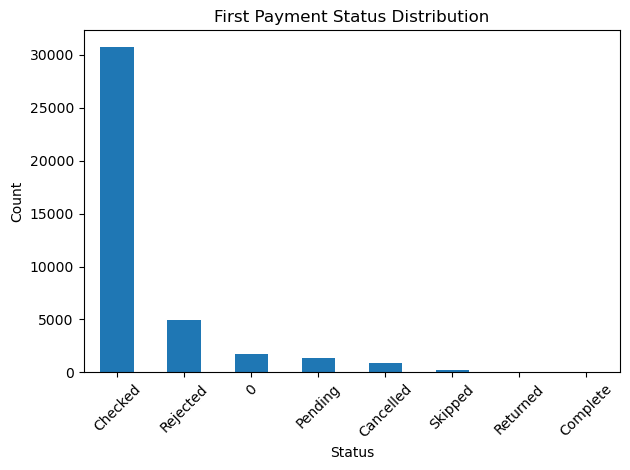

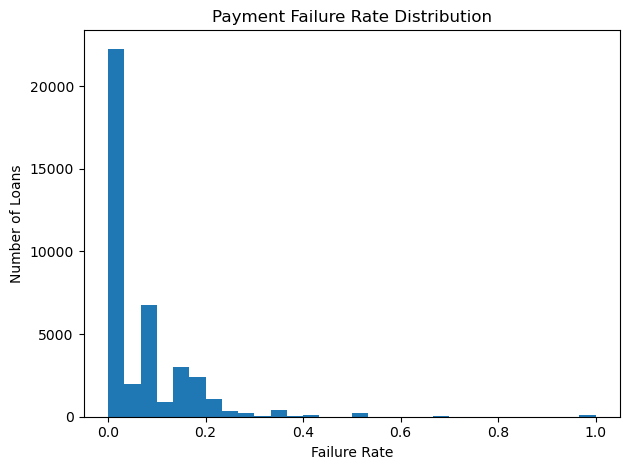

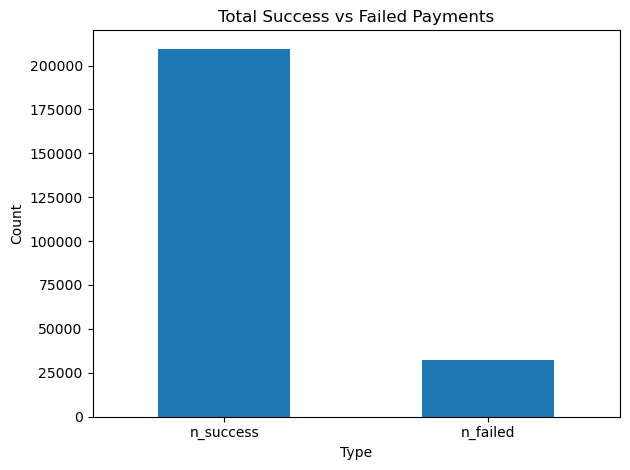

In [32]:
import numpy as np
import matplotlib.pyplot as plt

# ─────────────────────────────────────────────
# 1. Copy data
# ─────────────────────────────────────────────
pay = payment.copy()
regular = pay[pay['isCollection'] == False]

# ─────────────────────────────────────────────
# 2. Define payment status groups
# ─────────────────────────────────────────────
success_status = ['Checked', 'Complete']
fail_status = ['Rejected', 'Rejected Awaiting Retry', 'Returned']
neutral_status = ['Pending', 'Skipped', 'Cancelled']

pay['is_success'] = pay['paymentStatus'].isin(success_status)
pay['is_fail'] = pay['paymentStatus'].isin(fail_status)
pay['is_neutral'] = pay['paymentStatus'].isin(neutral_status)

# ─────────────────────────────────────────────
# 3. Aggregate features per loan
# ─────────────────────────────────────────────
payment_eda = pay.groupby('loanId').agg(

    total_payments=('paymentStatus', 'count'),

    n_success=('is_success', 'sum'),
    n_failed=('is_fail', 'sum'),
    n_neutral=('is_neutral', 'sum'),

    n_cancelled=('paymentStatus', lambda x: (x == 'Cancelled').sum()),
    n_skipped=('paymentStatus', lambda x: (x == 'Skipped').sum()),

    has_collection_plan=('isCollection', lambda x: int(x.any())),

).reset_index()

# ─────────────────────────────────────────────
# 4. First payment behavior
# ─────────────────────────────────────────────
first_pay = (
    regular[regular['installmentIndex'] == 1]
    .groupby('loanId')['paymentStatus']
    .first()
    .reset_index()
    .rename(columns={'paymentStatus': 'first_payment_status'})
)

payment_eda = payment_eda.merge(first_pay, on='loanId', how='left')

payment_eda['first_payment_failed'] = (
    payment_eda['first_payment_status'].isin(fail_status)
).astype(int)

# ─────────────────────────────────────────────
# 5. Risk ratios
# ─────────────────────────────────────────────
payment_eda['pct_payments_failed'] = (
    payment_eda['n_failed'] /
    payment_eda['total_payments'].replace(0, np.nan)
)

payment_eda['pct_payments_success'] = (
    payment_eda['n_success'] /
    payment_eda['total_payments'].replace(0, np.nan)
)

# fill missing safely
payment_eda = payment_eda.fillna(0)

# ─────────────────────────────────────────────
# 6. PRINT SUMMARY
# ─────────────────────────────────────────────
print("Payment EDA shape:", payment_eda.shape)
print("\nFirst payment status distribution:")
print(payment_eda['first_payment_status'].value_counts())

# ─────────────────────────────────────────────
# 7. VISUALIZATION
# ─────────────────────────────────────────────

# First payment distribution
plt.figure()
payment_eda['first_payment_status'].value_counts().plot(kind='bar')
plt.title("First Payment Status Distribution")
plt.xlabel("Status")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Failure rate distribution
plt.figure()
payment_eda['pct_payments_failed'].plot(kind='hist', bins=30)
plt.title("Payment Failure Rate Distribution")
plt.xlabel("Failure Rate")
plt.ylabel("Number of Loans")
plt.tight_layout()
plt.show()

# Success vs failure comparison
plt.figure()
payment_eda[['n_success', 'n_failed']].sum().plot(kind='bar')
plt.title("Total Success vs Failed Payments")
plt.xlabel("Type")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# Target Distribution

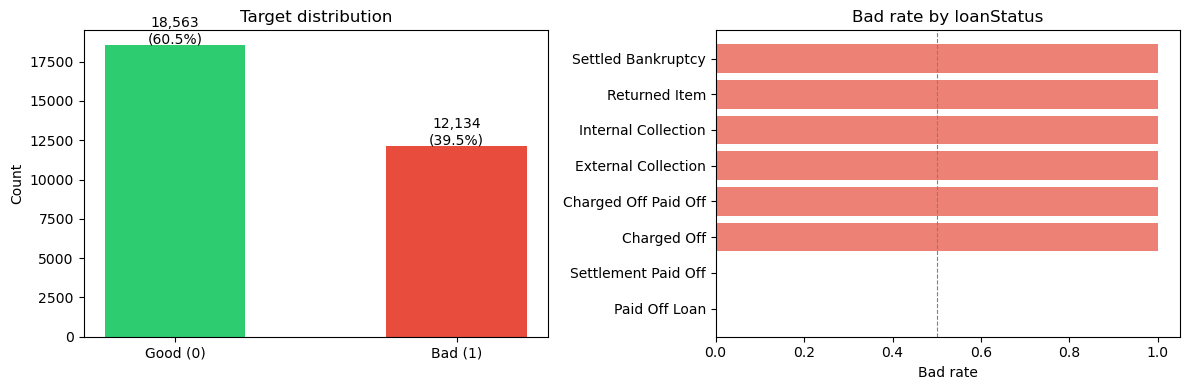

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Target counts
counts = model_df['target'].value_counts()
axes[0].bar(['Good (0)', 'Bad (1)'], counts.values, color=['#2ecc71','#e74c3c'], width=0.5)
axes[0].set_title('Target distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 100, f'{v:,}\n({v/len(model_df):.1%})', ha='center', fontsize=10)

# Bad rate by loanStatus (to justify label choices)
bad_by_status = (df.groupby('loanStatus')['target']
                 .mean()
                 .sort_values(ascending=True))
axes[1].barh(bad_by_status.index, bad_by_status.values, color='#e74c3c', alpha=0.7)
axes[1].set_title('Bad rate by loanStatus')
axes[1].set_xlabel('Bad rate')
axes[1].axvline(0.5, linestyle='--', color='gray', linewidth=0.8)

plt.tight_layout()
plt.show()

# Key Risk Drivers

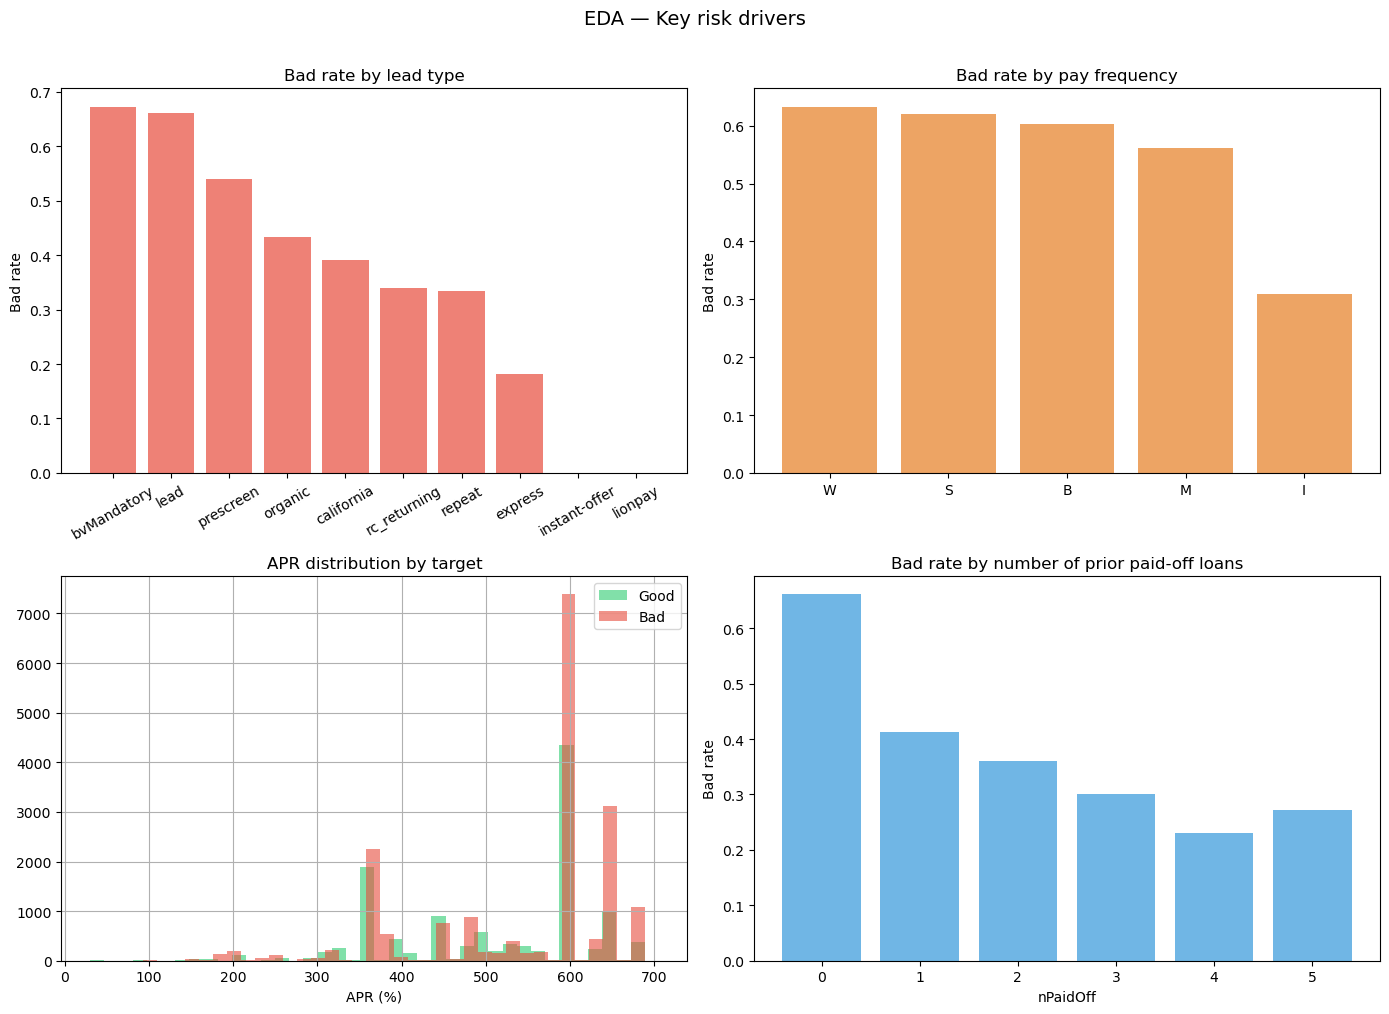

In [34]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Bad rate by leadType
lr = model_df.groupby('leadType')['target'].mean().sort_values(ascending=False)
axes[0,0].bar(lr.index, lr.values, color='#e74c3c', alpha=0.7)
axes[0,0].set_title('Bad rate by lead type')
axes[0,0].set_ylabel('Bad rate')
axes[0,0].tick_params(axis='x', rotation=30)

# 2. Bad rate by payFrequency
pr = model_df.groupby('payFrequency')['target'].mean().sort_values(ascending=False)
axes[0,1].bar(pr.index, pr.values, color='#e67e22', alpha=0.7)
axes[0,1].set_title('Bad rate by pay frequency')
axes[0,1].set_ylabel('Bad rate')

# 3. APR distribution by target
model_df[model_df['target']==0]['apr'].hist(ax=axes[1,0], bins=40, alpha=0.6, color='#2ecc71', label='Good')
model_df[model_df['target']==1]['apr'].hist(ax=axes[1,0], bins=40, alpha=0.6, color='#e74c3c', label='Bad')
axes[1,0].set_title('APR distribution by target')
axes[1,0].set_xlabel('APR (%)')
axes[1,0].legend()

# 4. nPaidOff vs bad rate
npaid = model_df.groupby('nPaidOff')['target'].mean().reset_index()
npaid = npaid[npaid['nPaidOff'] <= 5]
axes[1,1].bar(npaid['nPaidOff'], npaid['target'], color='#3498db', alpha=0.7)
axes[1,1].set_title('Bad rate by number of prior paid-off loans')
axes[1,1].set_xlabel('nPaidOff')
axes[1,1].set_ylabel('Bad rate')

plt.suptitle('EDA — Key risk drivers', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Point-biserial correlation (Numerical Features vs Binary Target) (Strength and Direction) (p<0.05 significant) (correlation + more likely bad loan)

                         feature  correlation       p_value significant
                        nPaidOff    -0.200616 3.557328e-276         Yes
                     fraud_score    -0.186579 1.660077e-238         Yes
                             apr     0.128836 9.605138e-114         Yes
                        inq_365d     0.076837  2.003262e-41         Yes
                         inq_90d     0.072639  3.405616e-37         Yes
                         inq_30d     0.055717  1.527967e-22         Yes
              n_fraud_indicators     0.054194  2.066490e-21         Yes
                          inq_7d     0.036794  1.130451e-10         Yes
originallyScheduledPaymentAmount     0.025902  5.659036e-06         Yes
                        leadCost    -0.013741  1.605959e-02         Yes
                      loanAmount    -0.011653  4.118068e-02         Yes


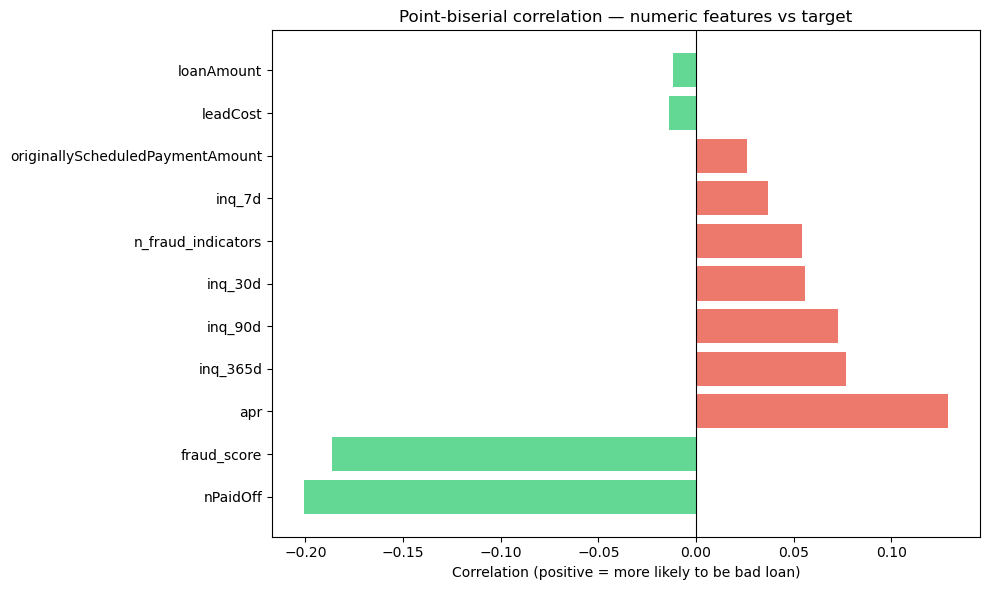

In [35]:
from scipy import stats

numeric_features = [
    'apr', 'loanAmount', 'originallyScheduledPaymentAmount',
    'nPaidOff', 'leadCost', 'fraud_score', 'n_fraud_indicators',
    'inq_7d', 'inq_30d', 'inq_90d', 'inq_365d',
]

corr_results = []
for col in numeric_features:
    temp = model_df[[col, 'target']].dropna()
    corr, pval = stats.pointbiserialr(temp['target'], temp[col])
    corr_results.append({
        'feature': col,
        'correlation': corr,
        'p_value': pval,
        'significant': 'Yes' if pval < 0.05 else 'No'
    })

corr_df = pd.DataFrame(corr_results).sort_values('correlation', key=abs, ascending=False)
print(corr_df.to_string(index=False))

# Plot
plt.figure(figsize=(10, 6))
colors = ['#e74c3c' if v > 0 else '#2ecc71' for v in corr_df['correlation']]
plt.barh(corr_df['feature'], corr_df['correlation'], color=colors, alpha=0.75)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Point-biserial correlation — numeric features vs target')
plt.xlabel('Correlation (positive = more likely to be bad loan)')
plt.tight_layout()
plt.show()

# Chi-square test (Categorical Features vs Binary Target) (chi2_statistic + strong relationship) (p<0.05 significant)

In [36]:
from scipy.stats import chi2_contingency

cat_features = ['payFrequency', 'leadType', 'state']

chi2_results = []
for col in cat_features:
    temp = model_df[[col, 'target']].dropna()
    contingency = pd.crosstab(temp[col], temp['target'])
    chi2, pval, dof, _ = chi2_contingency(contingency)
    chi2_results.append({
        'feature': col,
        'chi2_statistic': round(chi2, 2),
        'p_value': round(pval, 6),
        'degrees_of_freedom': dof,
        'significant': 'Yes' if pval < 0.05 else 'No'
    })

chi2_df = pd.DataFrame(chi2_results).sort_values('chi2_statistic', ascending=False)
print(chi2_df.to_string(index=False))

     feature  chi2_statistic  p_value  degrees_of_freedom significant
    leadType         1481.40      0.0                   9         Yes
       state         1333.50      0.0                  40         Yes
payFrequency          202.12      0.0                   4         Yes


# Mann-Whitney U test (Numeric Features vs Binary target) (if the distributions are significantly different between good and bad loans (significance)) (p<0.05 significant)

In [37]:
from scipy.stats import mannwhitneyu

mw_results = []
for col in numeric_features:
    temp = model_df[[col, 'target']].dropna()
    good = temp[temp['target'] == 0][col]
    bad  = temp[temp['target'] == 1][col]
    stat, pval = mannwhitneyu(good, bad, alternative='two-sided')
    mw_results.append({
        'feature': col,
        'mean_good': round(good.mean(), 3),
        'mean_bad':  round(bad.mean(), 3),
        'p_value':   round(pval, 6),
        'significant': 'Yes' if pval < 0.05 else 'No'
    })

mw_df = pd.DataFrame(mw_results).sort_values('p_value')
print(mw_df.to_string(index=False))

                         feature  mean_good  mean_bad  p_value significant
                             apr    509.731   540.894 0.000000         Yes
originallyScheduledPaymentAmount   1660.366  1725.149 0.000000         Yes
                        nPaidOff      0.597     0.182 0.000000         Yes
                        leadCost     12.042    11.442 0.000000         Yes
                     fraud_score    709.211   663.732 0.000000         Yes
              n_fraud_indicators      2.025     2.153 0.000000         Yes
                          inq_7d      5.213     5.523 0.000000         Yes
                         inq_30d      6.861     7.586 0.000000         Yes
                         inq_90d      9.554    11.103 0.000000         Yes
                        inq_365d     17.459    21.049 0.000000         Yes
                      loanAmount    628.225   617.272 0.000009         Yes


# First payment failure (EDA)

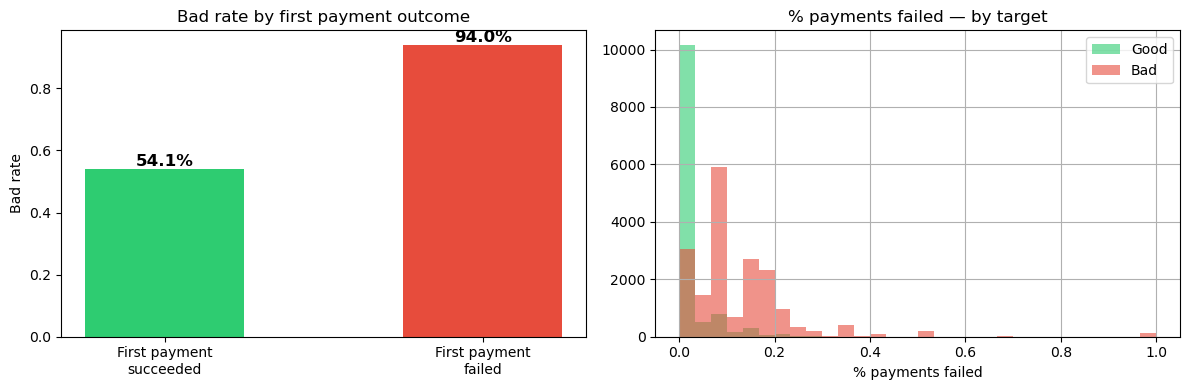


Key insight: A failed first payment is a very strong default signal.
  Bad rate when first payment succeeded: 54.1%
  Bad rate when first payment failed:    94.0%


In [38]:
fp_rate = model_df.groupby('first_payment_failed')['target'].mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(['First payment\nsucceeded', 'First payment\nfailed'],
            fp_rate.values, color=['#2ecc71','#e74c3c'], width=0.5)
axes[0].set_title('Bad rate by first payment outcome')
axes[0].set_ylabel('Bad rate')
for i, v in enumerate(fp_rate.values):
    axes[0].text(i, v + 0.01, f'{v:.1%}', ha='center', fontsize=12, fontweight='bold')

# pct_payments_failed distribution
model_df[model_df['target']==0]['pct_payments_failed'].hist(
    ax=axes[1], bins=30, alpha=0.6, color='#2ecc71', label='Good')
model_df[model_df['target']==1]['pct_payments_failed'].hist(
    ax=axes[1], bins=30, alpha=0.6, color='#e74c3c', label='Bad')
axes[1].set_title('% payments failed — by target')
axes[1].set_xlabel('% payments failed')
axes[1].legend()

plt.tight_layout()
plt.show()

print("\nKey insight: A failed first payment is a very strong default signal.")
print(f"  Bad rate when first payment succeeded: {fp_rate[0]:.1%}")
print(f"  Bad rate when first payment failed:    {fp_rate[1]:.1%}")

# Feature Selection Step 1

In [39]:
# ── Feature selection ──────────────────────────────────────────────────────
# Two-step approach:
# Step 1: Filter method — drop features not significant in statistical tests
# Step 2: Model-based — drop near-zero importance features after XGBoost
# ──────────────────────────────────────────────────────────────────────────

# Step 1: Collect p-values from previous tests
# Numeric features — use Mann-Whitney p-values (more reliable for skewed data)
mw_significant = mw_df[mw_df['significant'] == 'Yes']['feature'].tolist()
mw_dropped     = mw_df[mw_df['significant'] == 'No']['feature'].tolist()

# Categorical features — use chi-square p-values
chi2_significant = chi2_df[chi2_df['significant'] == 'Yes']['feature'].tolist()
chi2_dropped     = chi2_df[chi2_df['significant'] == 'No']['feature'].tolist()

print("=== Step 1: Filter method results ===")
print(f"\nNumeric features kept ({len(mw_significant)}):")
for f in mw_significant: print(f"  + {f}")
print(f"\nNumeric features dropped — not significant ({len(mw_dropped)}):")
for f in mw_dropped: print(f"  - {f}")
print(f"\nCategorical features kept ({len(chi2_significant)}):")
for f in chi2_significant: print(f"  + {f}")
print(f"\nCategorical features dropped — not significant ({len(chi2_dropped)}):")
for f in chi2_dropped: print(f"  - {f}")

# Always keep these regardless (domain knowledge)
always_keep = ['first_payment_failed', 'pct_payments_failed', 
               'has_collection_plan', 'is_repeat_customer',
               'has_clarity_data']

# Final selected features after Step 1
selected_features = list(set(
    mw_significant + chi2_significant + always_keep
))

print(f"\nTotal features selected after Step 1: {len(selected_features)}")

=== Step 1: Filter method results ===

Numeric features kept (11):
  + apr
  + originallyScheduledPaymentAmount
  + nPaidOff
  + leadCost
  + fraud_score
  + n_fraud_indicators
  + inq_7d
  + inq_30d
  + inq_90d
  + inq_365d
  + loanAmount

Numeric features dropped — not significant (0):

Categorical features kept (3):
  + leadType
  + state
  + payFrequency

Categorical features dropped — not significant (0):

Total features selected after Step 1: 19


# Modelling 

# Prepare features

In [40]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Only application-time features are included.
# Payment features are intentionally excluded:
#   ✗ first_payment_failed   — post-funding outcome
#   ✗ pct_payments_failed    — post-funding outcome
#   ✗ has_collection_plan    — post-funding outcome
#   ✗ n_rejected, n_checked  — post-funding outcome

# Use selected_features (statistically significant features) but also do a safety check to ensure all exist in model_df

application_time_features = [
    # Loan features
    'apr', 'loanAmount', 'originallyScheduledPaymentAmount',
    'leadCost', 'nPaidOff', 'is_repeat_customer', 'app_month',
    # Categorical
    'payFrequency', 'state', 'leadType',
    # Clarity features
    'has_clarity_data', 'fraud_score', 'n_fraud_indicators',
    'inq_7d', 'inq_30d', 'inq_90d', 'inq_365d',
    'addr_high_risk', 'many_inq_30d', 'ssn_belongs_to_another',
]

try:
    # Filter selected_features to only keep application-time ones
    payment_cols = ['first_payment_failed', 'pct_payments_failed',
                    'has_collection_plan', 'n_rejected', 'n_checked',
                    'n_success', 'n_cancelled', 'n_skipped',
                    'total_payments', 'total_paid']
    feature_cols = [f for f in selected_features 
                    if f not in payment_cols 
                    and f in model_df.columns]
    print("Using selected_features (filtered to application-time only)")
except NameError:
    feature_cols = [f for f in application_time_features 
                    if f in model_df.columns]
    print("selected_features not found — using application_time_features")

print(f"\nFinal feature count: {len(feature_cols)}")
print("Features:")
for f in feature_cols:
    print(f"  ✓ {f}")

# ── Build X and y ──────────────────────────────────────────────────────────
X = model_df[feature_cols].copy()
y = model_df['target'].copy()

# ── Encode categoricals ────────────────────────────────────────────────────
le_payfreq  = LabelEncoder()
le_leadtype = LabelEncoder()
le_state    = LabelEncoder()

if 'payFrequency' in X.columns:
    X['payFrequency'] = le_payfreq.fit_transform(X['payFrequency'].astype(str))
if 'leadType' in X.columns:
    X['leadType'] = le_leadtype.fit_transform(X['leadType'].astype(str))
if 'state' in X.columns:
    X['state'] = le_state.fit_transform(X['state'].astype(str))

# ── Fill remaining nulls with median ──────────────────────────────────────
X = X.fillna(X.median(numeric_only=True))

print(f"\nFeature matrix shape: {X.shape}")
print(f"Target shape:         {y.shape}")
print(f"Bad rate:             {y.mean():.1%}")
print(f"Class balance:        {(y==0).sum()} good / {(y==1).sum()} bad")

Using selected_features (filtered to application-time only)

Final feature count: 16
Features:
  ✓ inq_7d
  ✓ n_fraud_indicators
  ✓ loanAmount
  ✓ is_repeat_customer
  ✓ originallyScheduledPaymentAmount
  ✓ leadType
  ✓ state
  ✓ payFrequency
  ✓ inq_90d
  ✓ fraud_score
  ✓ apr
  ✓ has_clarity_data
  ✓ leadCost
  ✓ nPaidOff
  ✓ inq_30d
  ✓ inq_365d

Feature matrix shape: (30697, 16)
Target shape:         (30697,)
Bad rate:             60.5%
Class balance:        12134 good / 18563 bad


# Train/test split + Logistic Regression

In [41]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_curve,
    average_precision_score,
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

# Baseline: Logistic Regression
lr_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

lr_probs = lr_model.predict_proba(X_test)[:, 1]
lr_auc   = roc_auc_score(y_test, lr_probs)
print(f"\nLogistic Regression AUC: {lr_auc:.4f}")

Train: (24557, 16), Test: (6140, 16)

Logistic Regression AUC: 0.6772


C:\Users\Nitro\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


# XGBoost

In [42]:
import xgboost as xgb

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),  # handle imbalance
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='auc',
    random_state=42,
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False,
)

xgb_probs = xgb_model.predict_proba(X_test)[:, 1]
xgb_auc   = roc_auc_score(y_test, xgb_probs)
print(f"XGBoost AUC: {xgb_auc:.4f}")

C:\Users\Nitro\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [18:20:31] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost AUC: 0.7341


# Feature selection Step 2

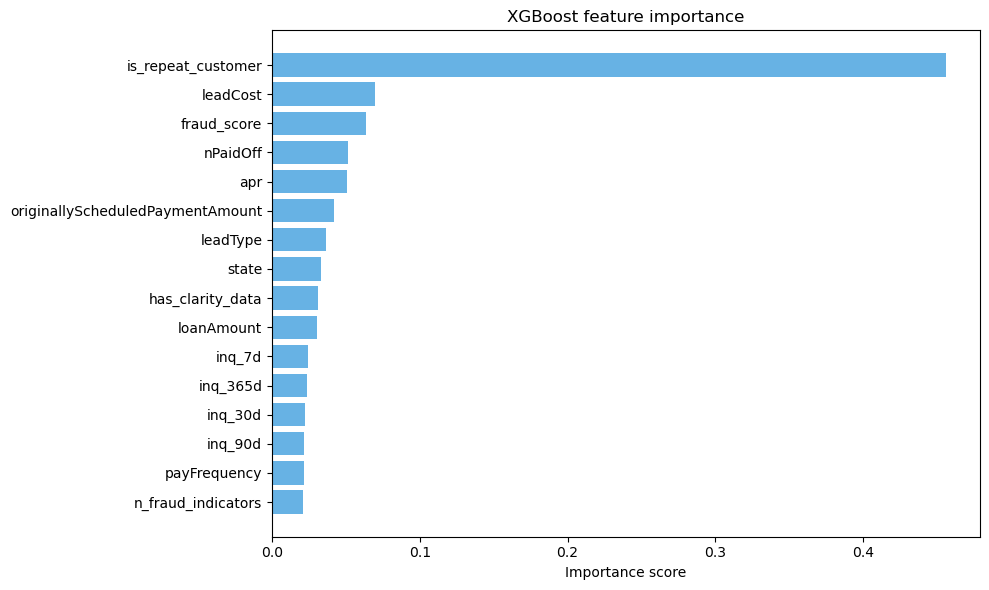


Features dropped — near-zero importance (0):

Final features kept (16):
  + is_repeat_customer
  + leadCost
  + fraud_score
  + nPaidOff
  + apr
  + originallyScheduledPaymentAmount
  + leadType
  + state
  + has_clarity_data
  + loanAmount
  + inq_7d
  + inq_365d
  + inq_30d
  + inq_90d
  + payFrequency
  + n_fraud_indicators

XGBoost AUC before feature selection: 0.7341
XGBoost AUC after feature selection:  0.7339
(AUC should be similar or better — fewer features, less noise)


In [43]:
# ── Step 2: Drop near-zero importance features from XGBoost ───────────────
import matplotlib.pyplot as plt

importance_df = pd.DataFrame({
    'feature':   feature_cols,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

# Plot feature importances
plt.figure(figsize=(10, 6))
plt.barh(importance_df['feature'], importance_df['importance'], color='#3498db', alpha=0.75)
plt.title('XGBoost feature importance')
plt.xlabel('Importance score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Drop features with near-zero importance (< 1% of max importance)
threshold = 0.01 * importance_df['importance'].max()
low_importance = importance_df[importance_df['importance'] < threshold]['feature'].tolist()
final_features = importance_df[importance_df['importance'] >= threshold]['feature'].tolist()

print(f"\nFeatures dropped — near-zero importance ({len(low_importance)}):")
for f in low_importance: print(f"  - {f}")
print(f"\nFinal features kept ({len(final_features)}):")
for f in final_features: print(f"  + {f}")

# Optional: refit XGBoost with final features only
X_train_final = X_train[final_features]
X_test_final  = X_test[final_features]

xgb_final = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    scale_pos_weight=(y_train==0).sum() / (y_train==1).sum(),
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='auc',
    random_state=42,
)
xgb_final.fit(X_train_final, y_train, 
              eval_set=[(X_test_final, y_test)], 
              verbose=False)

final_probs = xgb_final.predict_proba(X_test_final)[:, 1]
final_auc   = roc_auc_score(y_test, final_probs)

print(f"\nXGBoost AUC before feature selection: {xgb_auc:.4f}")
print(f"XGBoost AUC after feature selection:  {final_auc:.4f}")
print("(AUC should be similar or better — fewer features, less noise)")

# Evaluation & ROC curve

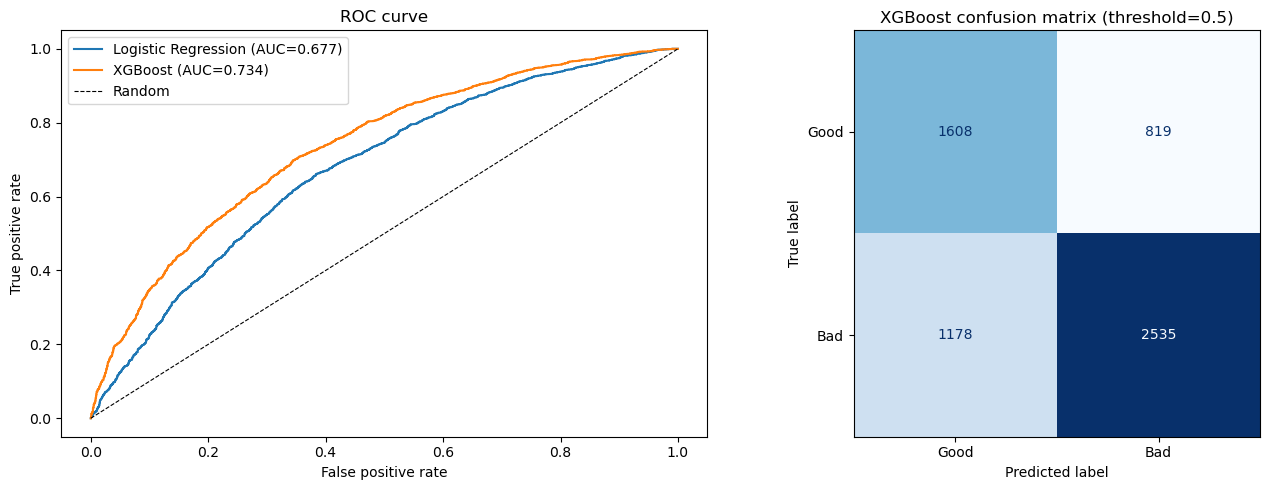

XGBoost Classification Report:
              precision    recall  f1-score   support

        Good       0.58      0.66      0.62      2427
         Bad       0.76      0.68      0.72      3713

    accuracy                           0.67      6140
   macro avg       0.67      0.67      0.67      6140
weighted avg       0.69      0.67      0.68      6140


--- Credit Risk Metrics ---
KS Statistic:     0.3534  (higher = better separation)
Gini Coefficient: 0.4682  (2*AUC - 1)

KS Grade: Good


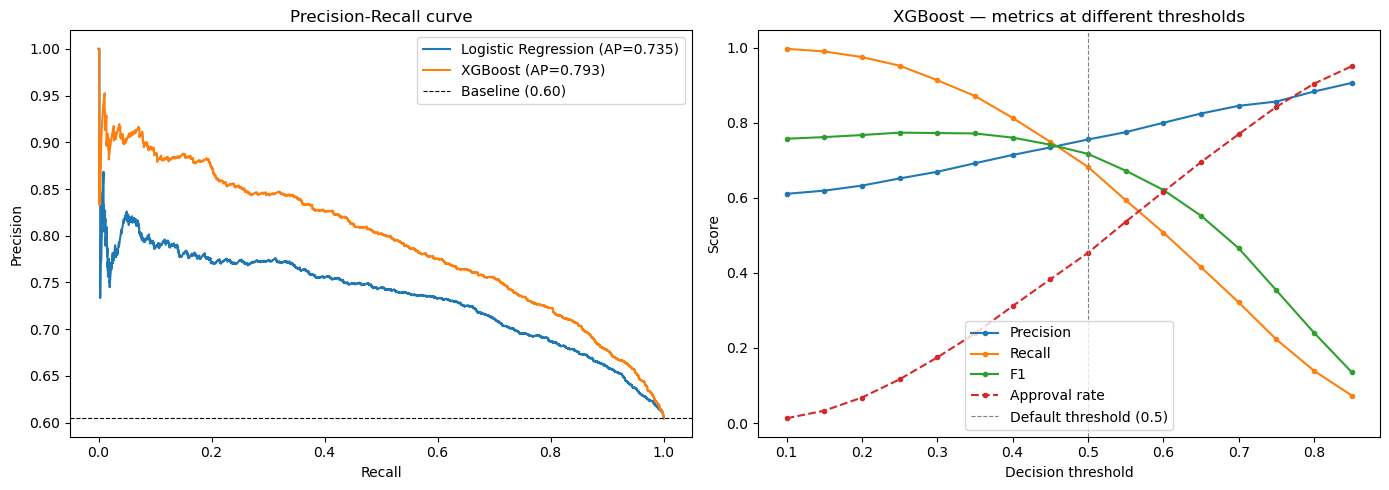


--- Model Comparison Summary ---
              Model  AUC-ROC   Gini  KS Statistic  Avg Precision
Logistic Regression   0.6772 0.3543        0.2768         0.7347
            XGBoost   0.7341 0.4682        0.3534         0.7933


In [44]:
import numpy as np

from sklearn.metrics import (roc_auc_score, roc_curve,
                             classification_report, confusion_matrix,
                             ConfusionMatrixDisplay,
                             precision_recall_curve, average_precision_score)
from scipy.stats import ks_2samp

# ── 1. ROC Curve ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, probs in [('Logistic Regression', lr_probs), 
                    ('XGBoost', xgb_probs)]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')

axes[0].plot([0,1],[0,1],'k--', linewidth=0.8, label='Random')
axes[0].set_title('ROC curve')
axes[0].set_xlabel('False positive rate')
axes[0].set_ylabel('True positive rate')
axes[0].legend()

# ── 2. Confusion Matrix ────────────────────────────────────────────────────
xgb_preds = (xgb_probs >= 0.5).astype(int)
cm = confusion_matrix(y_test, xgb_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=['Good','Bad'])
disp.plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('XGBoost confusion matrix (threshold=0.5)')

plt.tight_layout()
plt.show()

# ── 3. Classification Report ───────────────────────────────────────────────
print("XGBoost Classification Report:")
print(classification_report(y_test, xgb_preds, 
                            target_names=['Good','Bad']))

# ── 4. KS Statistic ───────────────────────────────────────────────────────
# Standard credit risk metric — measures separation between
# good and bad loan score distributions
good_probs = xgb_probs[y_test == 0]
bad_probs  = xgb_probs[y_test == 1]
ks_stat, ks_pval = ks_2samp(good_probs, bad_probs)

print(f"\n--- Credit Risk Metrics ---")
print(f"KS Statistic:     {ks_stat:.4f}  (higher = better separation)")
print(f"Gini Coefficient: {2 * roc_auc_score(y_test, xgb_probs) - 1:.4f}  (2*AUC - 1)")
print()

# KS interpretation
if ks_stat >= 0.4:
    ks_grade = 'Excellent'
elif ks_stat >= 0.3:
    ks_grade = 'Good'
elif ks_stat >= 0.2:
    ks_grade = 'Acceptable'
else:
    ks_grade = 'Poor'
print(f"KS Grade: {ks_grade}")

# ── 5. Precision-Recall Curve ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, probs in [('Logistic Regression', lr_probs),
                    ('XGBoost', xgb_probs)]:
    precision, recall, _ = precision_recall_curve(y_test, probs)
    ap = average_precision_score(y_test, probs)
    axes[0].plot(recall, precision, 
                 label=f'{name} (AP={ap:.3f})')

axes[0].axhline(y=y_test.mean(), color='k', linestyle='--', 
                linewidth=0.8, label=f'Baseline ({y_test.mean():.2f})')
axes[0].set_title('Precision-Recall curve')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].legend()

# ── 6. Threshold Analysis ─────────────────────────────────────────────────
thresholds = np.arange(0.1, 0.9, 0.05)
precisions, recalls, f1s, approval_rates = [], [], [], []

for t in thresholds:
    preds = (xgb_probs >= t).astype(int)
    tp = ((preds==1) & (y_test==1)).sum()
    fp = ((preds==1) & (y_test==0)).sum()
    fn = ((preds==0) & (y_test==1)).sum()
    
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec  = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1   = 2*prec*rec / (prec+rec) if (prec+rec) > 0 else 0
    approval = (preds == 0).mean()  # % loans approved (predicted good)
    
    precisions.append(prec)
    recalls.append(rec)
    f1s.append(f1)
    approval_rates.append(approval)

axes[1].plot(thresholds, precisions, label='Precision', marker='o', markersize=3)
axes[1].plot(thresholds, recalls,    label='Recall',    marker='o', markersize=3)
axes[1].plot(thresholds, f1s,        label='F1',        marker='o', markersize=3)
axes[1].plot(thresholds, approval_rates, label='Approval rate', 
             marker='o', markersize=3, linestyle='--')
axes[1].axvline(x=0.5, color='gray', linestyle='--', 
                linewidth=0.8, label='Default threshold (0.5)')
axes[1].set_title('XGBoost — metrics at different thresholds')
axes[1].set_xlabel('Decision threshold')
axes[1].set_ylabel('Score')
axes[1].legend()

plt.tight_layout()
plt.show()

# ── 7. Summary Table ──────────────────────────────────────────────────────
print("\n--- Model Comparison Summary ---")
summary = pd.DataFrame({
    'Model': ['Logistic Regression', 'XGBoost'],
    'AUC-ROC': [
        round(roc_auc_score(y_test, lr_probs), 4),
        round(roc_auc_score(y_test, xgb_probs), 4)
    ],
    'Gini': [
        round(2 * roc_auc_score(y_test, lr_probs) - 1, 4),
        round(2 * roc_auc_score(y_test, xgb_probs) - 1, 4)
    ],
    'KS Statistic': [
        round(ks_2samp(lr_probs[y_test==0], lr_probs[y_test==1])[0], 4),
        round(ks_stat, 4)
    ],
    'Avg Precision': [
        round(average_precision_score(y_test, lr_probs), 4),
        round(average_precision_score(y_test, xgb_probs), 4)
    ],
})
print(summary.to_string(index=False))

# SHAP feature importance

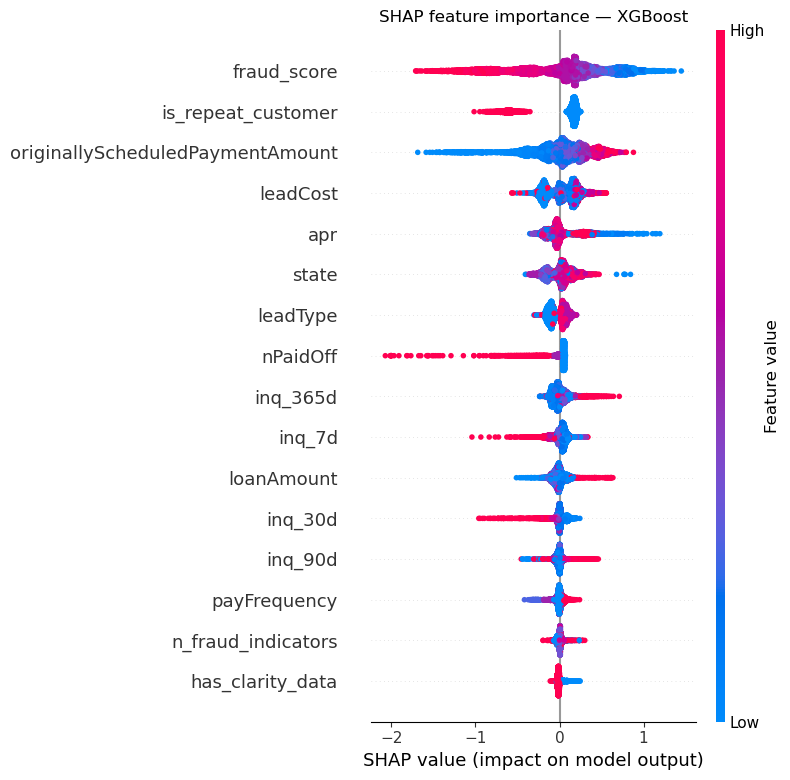

In [45]:
import shap

explainer  = shap.TreeExplainer(xgb_model)
shap_vals  = explainer.shap_values(X_test)

plt.figure(figsize=(10, 7))
shap.summary_plot(shap_vals, X_test, feature_names=feature_cols, show=False)
plt.title('SHAP feature importance — XGBoost')
plt.tight_layout()
plt.show()

# Deployment

In [46]:
def get_input(prompt, valid_options=None, input_type=float,
              default=None, min_val=None, max_val=None):
    """
    Helper to get validated user input with full error handling.
    Handles: type errors, range errors, invalid options, empty input.
    """
    while True:
        try:
            if valid_options:
                print(f"  Options: {valid_options}")

            raw = input(f"  {prompt}" +
                       (f" [default: {default}]: " if default is not None
                        else ": "))

            # Use default if Enter pressed
            if raw.strip() == '' and default is not None:
                print(f"  → Using default: {default}")
                return default

            # Empty with no default
            if raw.strip() == '' and default is None:
                print("  ✗ Input cannot be empty. Please enter a value.")
                continue

            # Validate against options
            if valid_options:
                if raw.strip() not in valid_options:
                    print(f"  ✗ '{raw.strip()}' is not valid.")
                    print(f"  ✗ Please choose from: {valid_options}")
                    continue
                return raw.strip()

            # Convert type
            converted = input_type(raw.strip())

            # Range check
            if min_val is not None and converted < min_val:
                print(f"  ✗ Value must be at least {min_val}. Got {converted}.")
                continue
            if max_val is not None and converted > max_val:
                print(f"  ✗ Value must be at most {max_val}. Got {converted}.")
                continue

            return converted

        except ValueError:
            print(f"  ✗ '{raw.strip()}' is not a valid {input_type.__name__}.")
            print(f"  ✗ Please enter a valid {input_type.__name__} value.")
        except KeyboardInterrupt:
            print("\n  Scorer cancelled by user.")
            return None


def yn_to_int(val):
    """Convert y/n string to 1/0 integer."""
    return 1 if val.lower() == 'y' else 0


def score_loan(apr, loan_amount, n_paid_off, pay_frequency,
               lead_type, state, fraud_score, has_clarity,
               inq_7d, inq_30d, inq_90d, inq_365d,
               n_fraud_indicators, addr_high_risk,
               many_inq_30d, ssn_belongs_to_another):
    """
    Score a loan application using ALL model features.

    Parameters:
        apr                   : Annual percentage rate
        loan_amount           : Loan amount in dollars
        n_paid_off            : Number of prior loans paid off
        pay_frequency         : B=Biweekly, W=Weekly, M=Monthly,
                                S=Semi-monthly, I=Irregular
        lead_type             : organic, bvMandatory, lead, prescreen,
                                repeat, rc_returning, express, instant-offer
        state                 : US state code (e.g. CA, NY, TX)
        fraud_score           : Clarity fraud score (0-1000)
        has_clarity           : 1 if clarity data available, 0 otherwise
        inq_7d                : Number of inquiries in last 7 days
        inq_30d               : Number of inquiries in last 30 days
        inq_90d               : Number of inquiries in last 90 days
        inq_365d              : Number of inquiries in last 365 days
        n_fraud_indicators    : Total number of fraud indicators triggered
        addr_high_risk        : 1 if inquiry address is high risk, else 0
        many_inq_30d          : 1 if more than 3 inquiries in last 30 days
        ssn_belongs_to_another: 1 if SSN likely belongs to another, else 0

    Returns:
        dict with decision, probability and reasoning
    """
    # ── Build baseline input using median values ───────────────────────────
    input_data = pd.DataFrame([{
        col: model_df[col].median()
             if col in model_df.columns
             and pd.api.types.is_numeric_dtype(model_df[col])
             else 0
        for col in final_features
    }])

    # ── Override with all user-provided inputs ─────────────────────────────
    overrides = {
        'apr':                    apr,
        'loanAmount':             loan_amount,
        'nPaidOff':               n_paid_off,
        'is_repeat_customer':     int(n_paid_off > 0),
        'fraud_score':            fraud_score,
        'has_clarity_data':       has_clarity,
        'inq_7d':                 inq_7d,
        'inq_30d':                inq_30d,
        'inq_90d':                inq_90d,
        'inq_365d':               inq_365d,
        'n_fraud_indicators':     n_fraud_indicators,
        'addr_high_risk':         addr_high_risk,
        'many_inq_30d':           many_inq_30d,
        'ssn_belongs_to_another': ssn_belongs_to_another,
    }

    for col, val in overrides.items():
        if col in input_data.columns:
            input_data[col] = val

    # ── Encode categorical features ────────────────────────────────────────
    for col, encoder, val in [
        ('payFrequency', le_payfreq,  pay_frequency),
        ('leadType',     le_leadtype, lead_type),
        ('state',        le_state,    state),
    ]:
        if col in input_data.columns:
            try:
                input_data[col] = encoder.transform([val])[0]
            except Exception:
                print(f"  ⚠ Warning: '{val}' not seen during training "
                      f"for {col}. Using default encoding.")
                input_data[col] = 0

    # ── Predict ────────────────────────────────────────────────────────────
    prob_bad  = xgb_final.predict_proba(
        input_data[final_features])[0][1]
    prob_good = 1 - prob_bad

    # ── Decision logic ─────────────────────────────────────────────────────
    if prob_bad < 0.3:
        decision = 'APPROVE'
        reason   = 'Low default risk — applicant profile is strong.'
    elif prob_bad < 0.5:
        decision = 'REVIEW'
        reason   = 'Moderate risk — manual review recommended.'
    else:
        decision = 'DECLINE'
        reason   = 'High default risk — does not meet risk threshold.'

    # ── Print result ───────────────────────────────────────────────────────
    print()
    print("=" * 55)
    print("         LOAN RISK PREDICTOR — RESULT")
    print("=" * 55)
    print(f"  Decision:              {decision}")
    print(f"  Default probability:   {prob_bad:.1%}")
    print(f"  Repayment probability: {prob_good:.1%}")
    print(f"  Reasoning:             {reason}")
    print("-" * 55)
    print("  APPLICANT DETAILS:")
    print(f"    APR:                    {apr}%")
    print(f"    Loan amount:            ${loan_amount:,.0f}")
    print(f"    Prior loans paid off:   {n_paid_off}")
    print(f"    Pay frequency:          {pay_frequency}")
    print(f"    Lead type:              {lead_type}")
    print(f"    State:                  {state}")
    print("-" * 55)
    print("  CLARITY BUREAU DETAILS:")
    print(f"    Has clarity data:       {'Yes' if has_clarity else 'No'}")
    print(f"    Fraud score:            {fraud_score}")
    print(f"    Fraud indicators:       {n_fraud_indicators}")
    print(f"    Inquiries (7d):         {inq_7d}")
    print(f"    Inquiries (30d):        {inq_30d}")
    print(f"    Inquiries (90d):        {inq_90d}")
    print(f"    Inquiries (365d):       {inq_365d}")
    print(f"    High risk address:      {'Yes' if addr_high_risk else 'No'}")
    print(f"    Many inquiries (30d):   {'Yes' if many_inq_30d else 'No'}")
    print(f"    SSN belongs to another: {'Yes' if ssn_belongs_to_another else 'No'}")
    print("=" * 55)
    print(f"  Note: All {len(final_features)} model features used for prediction.")
    print("=" * 55)

    return {
        'decision':        decision,
        'prob_default':    round(prob_bad, 4),
        'prob_repayment':  round(prob_good, 4),
        'reasoning':       reason,
        'features_used':   len(final_features),
    }


def run_scorer():
    """
    Interactive loan risk scorer — collects ALL model features from user.
    """
    print()
    print("=" * 55)
    print("      LOAN RISK PREDICTOR — INPUT MODE")
    print("=" * 55)
    print("  Enter applicant details below.")
    print("  Press Enter to use the default value.")
    print("  Press Ctrl+C at any time to cancel.")
    print("=" * 55)

    # ── Section 1: Loan details ────────────────────────────────────────────
    print()
    print("  --- Section 1: Loan Details ---")

    apr = get_input(
        "APR % (e.g. 450)",
        input_type=float, default=450,
        min_val=0.1, max_val=800,
    )
    if apr is None: return

    loan_amount = get_input(
        "Loan amount $ (100 - 5000)",
        input_type=float, default=500,
        min_val=100, max_val=5000,
    )
    if loan_amount is None: return

    n_paid_off = get_input(
        "Number of prior loans paid off (0 - 21)",
        input_type=int, default=0,
        min_val=0, max_val=21,
    )
    if n_paid_off is None: return

    pay_frequency = get_input(
        "Pay frequency (B=Biweekly, W=Weekly, M=Monthly, "
        "S=Semi-monthly, I=Irregular)",
        valid_options=['B', 'W', 'M', 'S', 'I'],
        input_type=str, default='B',
    )
    if pay_frequency is None: return

    lead_type = get_input(
        "Lead type",
        valid_options=['organic', 'bvMandatory', 'lead', 'prescreen',
                       'repeat', 'rc_returning', 'express', 'instant-offer'],
        input_type=str, default='organic',
    )
    if lead_type is None: return

    valid_states = sorted(model_df['state'].dropna().unique().tolist())
    state = get_input(
        "State code (e.g. CA, NY, TX)",
        valid_options=valid_states,
        input_type=str, default='CA',
    )
    if state is None: return

    # ── Section 2: Clarity bureau details ─────────────────────────────────
    print()
    print("  --- Section 2: Clarity Bureau Details ---")

    has_clarity_input = get_input(
        "Has clarity data? (y/n)",
        valid_options=['y', 'n', 'Y', 'N'],
        input_type=str, default='y',
    )
    if has_clarity_input is None: return
    has_clarity = yn_to_int(has_clarity_input)

    fraud_score = get_input(
        "Clarity fraud score (0 - 1000)",
        input_type=int, default=500,
        min_val=0, max_val=1000,
    )
    if fraud_score is None: return

    n_fraud_indicators = get_input(
        "Total number of fraud indicators triggered (0 - 20)",
        input_type=int, default=2,
        min_val=0, max_val=20,
    )
    if n_fraud_indicators is None: return

    # ── Section 3: Inquiry counts ──────────────────────────────────────────
    print()
    print("  --- Section 3: Inquiry History ---")

    inq_7d = get_input(
        "Number of credit inquiries in last 7 days",
        input_type=int, default=2,
        min_val=0, max_val=100,
    )
    if inq_7d is None: return

    inq_30d = get_input(
        "Number of credit inquiries in last 30 days",
        input_type=int, default=7,
        min_val=0, max_val=100,
    )
    if inq_30d is None: return

    inq_90d = get_input(
        "Number of credit inquiries in last 90 days",
        input_type=int, default=10,
        min_val=0, max_val=200,
    )
    if inq_90d is None: return

    inq_365d = get_input(
        "Number of credit inquiries in last 365 days",
        input_type=int, default=20,
        min_val=0, max_val=500,
    )
    if inq_365d is None: return

    # ── Section 4: Fraud flags ─────────────────────────────────────────────
    print()
    print("  --- Section 4: Fraud Flags ---")

    addr_high_risk_input = get_input(
        "Is inquiry address high risk? (y/n)",
        valid_options=['y', 'n', 'Y', 'N'],
        input_type=str, default='n',
    )
    if addr_high_risk_input is None: return
    addr_high_risk = yn_to_int(addr_high_risk_input)

    many_inq_30d_input = get_input(
        "More than 3 inquiries in last 30 days? (y/n)",
        valid_options=['y', 'n', 'Y', 'N'],
        input_type=str, default='n',
    )
    if many_inq_30d_input is None: return
    many_inq_30d = yn_to_int(many_inq_30d_input)

    ssn_input = get_input(
        "High probability SSN belongs to another person? (y/n)",
        valid_options=['y', 'n', 'Y', 'N'],
        input_type=str, default='n',
    )
    if ssn_input is None: return
    ssn_belongs_to_another = yn_to_int(ssn_input)

    # ── Run scorer ─────────────────────────────────────────────────────────
    try:
        result = score_loan(
            apr=apr,
            loan_amount=loan_amount,
            n_paid_off=n_paid_off,
            pay_frequency=pay_frequency,
            lead_type=lead_type,
            state=state,
            fraud_score=fraud_score,
            has_clarity=has_clarity,
            inq_7d=inq_7d,
            inq_30d=inq_30d,
            inq_90d=inq_90d,
            inq_365d=inq_365d,
            n_fraud_indicators=n_fraud_indicators,
            addr_high_risk=addr_high_risk,
            many_inq_30d=many_inq_30d,
            ssn_belongs_to_another=ssn_belongs_to_another,
        )
    except Exception as e:
        print(f"\n  ✗ Scoring error: {e}")
        print("  Please check your inputs and try again.")
        return

    # ── Ask to score another ───────────────────────────────────────────────
    print()
    try:
        another = input(
            "  Score another applicant? (y/n): "
        ).strip().lower()
        if another == 'y':
            run_scorer()
        else:
            print()
            print("  Thank you for using Loan Risk Predictor.")
            print("=" * 55)
    except KeyboardInterrupt:
        print("\n  Scorer exited.")


# ── Launch scorer ──────────────────────────────────────────────────────────
print("Launching Loan Risk Predictor...")
run_scorer()

Launching Loan Risk Predictor...

      LOAN RISK PREDICTOR — INPUT MODE
  Enter applicant details below.
  Press Enter to use the default value.
  Press Ctrl+C at any time to cancel.

  --- Section 1: Loan Details ---


  APR % (e.g. 450) [default: 450]:  215
  Loan amount $ (100 - 5000) [default: 500]:  2432
  Number of prior loans paid off (0 - 21) [default: 0]:  13


  Options: ['B', 'W', 'M', 'S', 'I']


  Pay frequency (B=Biweekly, W=Weekly, M=Monthly, S=Semi-monthly, I=Irregular) [default: B]:  M


  Options: ['organic', 'bvMandatory', 'lead', 'prescreen', 'repeat', 'rc_returning', 'express', 'instant-offer']


...

  Options: ['y', 'n', 'Y', 'N']


  High probability SSN belongs to another person? (y/n) [default: n]:  y



         LOAN RISK PREDICTOR — RESULT
  Decision:              REVIEW
  Default probability:   39.6%
  Repayment probability: 60.4%
  Reasoning:             Moderate risk — manual review recommended.
-------------------------------------------------------
  APPLICANT DETAILS:
    APR:                    215.0%
    Loan amount:            $2,432
    Prior loans paid off:   13
    Pay frequency:          M
    Lead type:              organic
    State:                  AK
-------------------------------------------------------
  CLARITY BUREAU DETAILS:
    Has clarity data:       Yes
    Fraud score:            420
    Fraud indicators:       15
    Inquiries (7d):         4
    Inquiries (30d):        2
    Inquiries (90d):        8
    Inquiries (365d):       17
    High risk address:      No
    Many inquiries (30d):   No
    SSN belongs to another: Yes
  Note: All 16 model features used for prediction.



  Score another applicant? (y/n):  n



  Thank you for using Loan Risk Predictor.


In [47]:
!jupyter nbconvert --to html LoanRiskAssessment.ipynb

[NbConvertApp] Converting notebook LoanRiskAssessment.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 11 image(s).
[NbConvertApp] Writing 1357070 bytes to LoanRiskAssessment.html
